In [1]:
names = open("./avengers.txt", "r").read().splitlines()
# print(f"avengers: {names},\ntotal_names: {len(names)}")

In [2]:
characters = sorted(set("".join(names)))
# print(f"characters:{characters}, len: {len(characters)}")

In [3]:
# int to char and vice versa
ctoi = {c:i+1 for i,c in enumerate(characters)}
ctoi["."]=0
itoc = {i:c for c,i in ctoi.items()}
# print(ctoi,"\n", itoc, f"\nlen:{len(itoc)}")

In [4]:
# bigram
xs = []
ys = []
for name in names:
    chs = ["."]+list(name)+["."]
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = ctoi[ch1]
        ix2 = ctoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
        

In [5]:
print(xs, "\n", ys, f"\nlen xs, ys: {len(xs)}, {len(ys)}")

[0, 14, 11, 10, 17, 0, 13, 14, 4, 16, 4, 0, 14, 6, 11, 12, 0, 9, 11, 8, 7, 0, 13, 14, 12, 1, 10, 5, 4, 0, 14, 3, 6, 1, 9, 9, 1, 0, 2, 12, 15, 3, 4, 0, 10, 1, 14, 1, 13, 6, 1] 
 [14, 11, 10, 17, 0, 13, 14, 4, 16, 4, 0, 14, 6, 11, 12, 0, 9, 11, 8, 7, 0, 13, 14, 12, 1, 10, 5, 4, 0, 14, 3, 6, 1, 9, 9, 1, 0, 2, 12, 15, 3, 4, 0, 10, 1, 14, 1, 13, 6, 1, 0] 
len xs, ys: 51, 51


In [6]:
import torch 
xst = torch.tensor(xs)
yst = torch.tensor(ys)
xst, yst

(tensor([ 0, 14, 11, 10, 17,  0, 13, 14,  4, 16,  4,  0, 14,  6, 11, 12,  0,  9,
         11,  8,  7,  0, 13, 14, 12,  1, 10,  5,  4,  0, 14,  3,  6,  1,  9,  9,
          1,  0,  2, 12, 15,  3,  4,  0, 10,  1, 14,  1, 13,  6,  1]),
 tensor([14, 11, 10, 17,  0, 13, 14,  4, 16,  4,  0, 14,  6, 11, 12,  0,  9, 11,
          8,  7,  0, 13, 14, 12,  1, 10,  5,  4,  0, 14,  3,  6,  1,  9,  9,  1,
          0,  2, 12, 15,  3,  4,  0, 10,  1, 14,  1, 13,  6,  1,  0]))

In [7]:
rg = torch.Generator().manual_seed(21479230)
total_unq_char = len(ctoi)
xenc = torch.nn.functional.one_hot(xst, num_classes=total_unq_char).float()

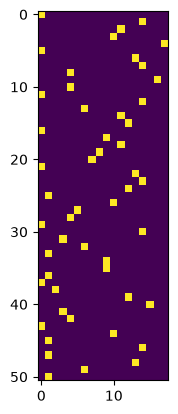

In [8]:
import matplotlib.pyplot as plt
plt.imshow(xenc)

In [9]:
weights = torch.randn((total_unq_char, total_unq_char), generator=rg, requires_grad=True)
weights

tensor([[-0.1362,  0.7515,  0.6361,  0.2978, -1.1523, -0.3092, -0.9447,  2.3070,
         -1.0713, -0.3241,  0.7571,  0.9620,  1.7304,  1.4355, -0.9281, -1.2005,
          0.3097, -1.3594],
        [-0.8440,  0.0190, -0.4900,  0.3503,  0.0183, -0.1561,  0.2924, -0.2154,
         -0.3946, -1.4958,  0.0916, -0.9838, -0.6318,  0.7677,  0.0834,  1.0932,
         -1.6008,  0.3516],
        [ 0.0209,  0.5717,  0.7703, -2.2789,  0.7656, -0.2542, -0.2939,  1.4964,
          0.1814, -1.6921,  0.4891, -1.9375, -0.4808,  1.7087, -1.1860,  0.2021,
          0.6438, -0.2063],
        [ 0.6424, -1.6601,  0.4450, -0.1133, -1.9519, -0.5352,  0.5255,  0.3440,
         -0.2872,  0.1084,  0.4209, -1.3055,  0.4434,  2.0303, -0.2721, -1.9086,
          1.1009,  1.9589],
        [-0.2831,  0.2219,  0.7821,  1.0578,  1.1459, -1.5019, -0.6519,  0.8825,
         -2.1384, -0.1311, -0.2020,  2.0228, -0.2094,  0.5919, -0.3264, -1.0114,
          0.3091, -0.2877],
        [-1.6878,  0.8623, -1.1089,  0.1534, -1.22

In [37]:
# training 
epochs = 10
n_iterations = 1000
learning_rate = 0.1
losses = []
for epoch in range(epochs):
    for iter in range(n_iterations):
        
        # forward pass 
        logits = xenc @ weights # logits
        counts = logits.exp() # counts
        probs = counts/counts.sum(1, keepdim=True) # softmax
        loss = - probs[torch.arange(len(xst.data)), yst].log().mean() # negative log likelihood (nll)
        losses.append(loss.item())
        
        # backward
        weights.grad = None
        loss.backward()
        
        # update 
        weights.data -= learning_rate * weights.grad
    
if (n_iterations>=5):
    print(f"last 5 lossess: {losses[len(losses)-5:]}")
print("last probs : ", probs)

IndexError: Dimension out of range (expected to be in range of [-1, 0], but got 1)

In [11]:
losses

[3.412504196166992,
 3.4095990657806396,
 3.406698226928711,
 3.4038002490997314,
 3.400907039642334,
 3.398017644882202,
 3.395132064819336,
 3.3922502994537354,
 3.389371871948242,
 3.386498212814331,
 3.3836278915405273,
 3.38076114654541,
 3.377899169921875,
 3.375040054321289,
 3.372185230255127,
 3.3693344593048096,
 3.3664867877960205,
 3.363643169403076,
 3.3608036041259766,
 3.3579676151275635,
 3.355135440826416,
 3.352306842803955,
 3.3494818210601807,
 3.346660852432251,
 3.343843936920166,
 3.3410301208496094,
 3.3382203578948975,
 3.335414171218872,
 3.3326117992401123,
 3.32981276512146,
 3.327017307281494,
 3.324225902557373,
 3.3214380741119385,
 3.3186538219451904,
 3.315873384475708,
 3.313096523284912,
 3.3103229999542236,
 3.3075528144836426,
 3.3047869205474854,
 3.3020243644714355,
 3.2992656230926514,
 3.2965099811553955,
 3.2937583923339844,
 3.2910099029541016,
 3.2882654666900635,
 3.285524368286133,
 3.2827866077423096,
 3.2800519466400146,
 3.27732157707214

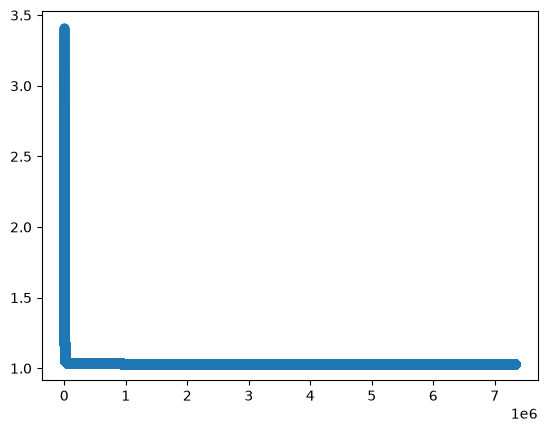

In [12]:
import numpy as np 
plt.scatter(x=np.arange(len(losses)),y=losses)
plt.show()

In [56]:
total_samples_req = 6
new_names = []
# rg = torch.Generator().manual_seed(21479230)
for i in range(total_samples_req):
    ix = 0
    out = []

    while True:
        xenc = torch.nn.functional.one_hot(
            torch.tensor(ix),
            num_classes=total_unq_char
        ).float()

        logits = xenc @ weights
        counts = logits.exp()
        probs = counts / counts.sum()

        ix = torch.multinomial(
            probs,
            num_samples=1,
            replacement=True,
            generator=rg
        ).item()

        ch = itoc[ix]
        out.append(ch)

        if ix == 0:
            break

    new_names.append("".join(out))

for new_name in new_names:
    print(new_name[:-1])

nashoki
stchona
thaloki
stceve
teve
tchona
